In [1]:
import subprocess as sub
sub.call("python Unbounded_setup.py build_ext --inplace",shell=True)

running build_ext
copying build/lib.macosx-11.1-arm64-cpython-312/UnboundedFilaments.cpython-312-darwin.so -> 


0

In [2]:
import UnboundedFilaments as filaments 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


## A 3t swimmer

A 3t swimmer movies with velocity 

$\mathbf V^{A} = v_s\, \mathbf p$

It created a fluid flow:


$$
v_i^{3t} = \frac{-2\pi\eta b^3}{5}\nabla^2  G_{ij}   V^{(3t)}_{j} = \frac12 
\left(\frac{b}{r}\right)^3 (3 \hat{r}_i \hat{r}_j - \delta_{ij}) V^A_j.
$$

Here $\mathbf{V}^{(3t)} = 5\mathbf{V}^{A}$

$V^A = vs \hat e$

In [3]:
def show_figure(fig, x, y, z, xl):
    ax_xy = fig.add_axes([0.05, 0.1, 0.4, 0.8])
    ax_xz = fig.add_axes([0.55, 0.1, 0.4, 0.8*(xl+2)/(2*xl)])

    z_min = np.clip(min(z)-2, -0.2, None);  z_max = min(z) + xl
    
    for i in range(len(x)):
        ax_xy.add_patch(patches.Circle((x[i], y[i]), 1, color='maroon', alpha = 0.32))
        ax_xz.add_patch(patches.Circle((x[i], z[i]), 1, color='maroon', alpha = 0.32))

    ax_xy.set_xlim(-xl, xl);  ax_xy.set_ylim(-xl, xl)
    ax_xz.set_xlim(-xl, xl);  ax_xz.set_ylim(z_min, z_max)

    ax_xy.set_xlabel('$x$');  ax_xy.set_ylabel('$y$', rotation = True)
    ax_xz.set_xlabel('$x$');  ax_xz.set_ylabel('$z$', rotation = True)
    
    ax_xy.grid(True);  ax_xz.grid(True)
    return ax_xy, ax_xz, z_min, z_max

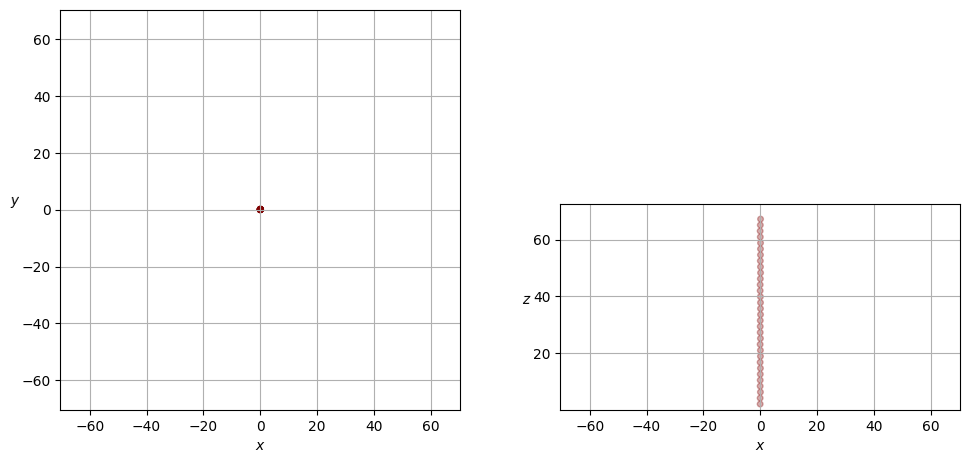

In [4]:
global particle, xl, b, eta, epsilon, dt_base, h, periodicity

particle = 32               # ======== Number of the particles ========
N=particle
b = 1.0                     # ======== Radius of the particle ========
dt_base = 0.01              # ======== For discreat integration, displacement in every step should be very small ========
epsilon = 3                 # ======== Strength of the inter-atomic force ========
eta = 1.0/6                     # ======== 
h = 1000*b                  # ======== Height of the particles from the lower plane =========
periodicity = 0
bondLength = 2.1*b
xl = 2*b*particle*1.1
lje = 1
ljr = 2.1*b
wlje = 10
wljr = 2.1*b

k_spring=25
bending_strength=13.125
x_initial = np.zeros(particle) 
z_initial = 2.1 + np.arange(particle)*bondLength 

x_initial[2:N] +=  .15*np.random.random(N-2)  ##perturbing the non-clamped particles

y_initial = np.zeros(particle)
y_initial[2:N] +=  .15*np.random.random(N-2)


show_figure(plt.figure(figsize = (10,5)), x_initial, y_initial, z_initial, xl);

In [32]:
vs=-0.74
sim = filaments.colloids(N, 0, b, eta, k_spring, vs, bending_strength, bondLength, lje, ljr)

In [33]:
import time
from scipy.integrate import solve_ivp

T_total=300
position0 = np.concatenate((x_initial, y_initial, z_initial))
integrator='LSODA'

dd = 300
t_eval = np.linspace(0, T_total, dd)

In [34]:
def rhs(t, position):
    sim.computeVel_3tClamp(position)
    return sim.VV

t1 = time.perf_counter()

sol = solve_ivp(rhs,[0, T_total], position0, method=integrator, t_eval=t_eval, rtol=1e-4, atol=1e-4)

t2 = time.perf_counter()

X = sol.y.T   # shape (dd, 3N)
tt = sol.t

In [35]:
np.shape(X)

(300, 96)

## Animation

In [36]:
from IPython.display import Video
from matplotlib.animation import FuncAnimation

In [37]:
fig=plt.figure(figsize=(5,5))#,dpi=100)
Nframe =50
facT=int(dd/Nframe)

def animation(Nframe, delay_time):
    
    def prog(i):
        plt.clf(); print(i, end=' ') 
        x, y =  X[i*facT, 0:N],  X[i*facT, 2*N:3*N]
        ax=plt.gca()
        plt.grid()
        plt.xlim(-5+np.min(x),5+np.max(x))
        plt.ylim(-2+np.min(y),5+np.max(y))
        plt.title('$t$=%1.2E s'%((i+1)*facT))
        plt.axis('equal')
        for j in range(N):
            ax.add_patch(patches.Circle((x[j],y[j]),b,color='maroon',alpha=0.32))
        
    anm = FuncAnimation(fig, prog, frames=Nframe, interval=delay_time, repeat=0)   # interval is Delay between frames in milliseconds.
    return anm
     
delay_time = 220  # Delay between frames in milliseconds.
anim = animation(Nframe, delay_time)
anim.save('output_polymer.mp4')
fig.clear()
plt.close(fig) 

0 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 

In [38]:
## show the video
Video('output_polymer.mp4')   